=== 모델 성능 ===
Accuracy: 0.9737
Precision: 0.9722
Recall: 0.9859
F1 Score: 0.9790


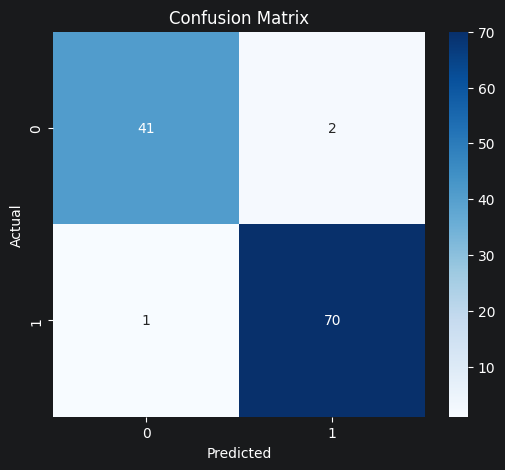

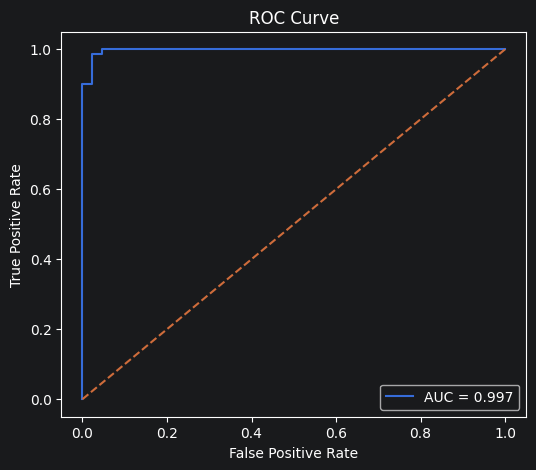

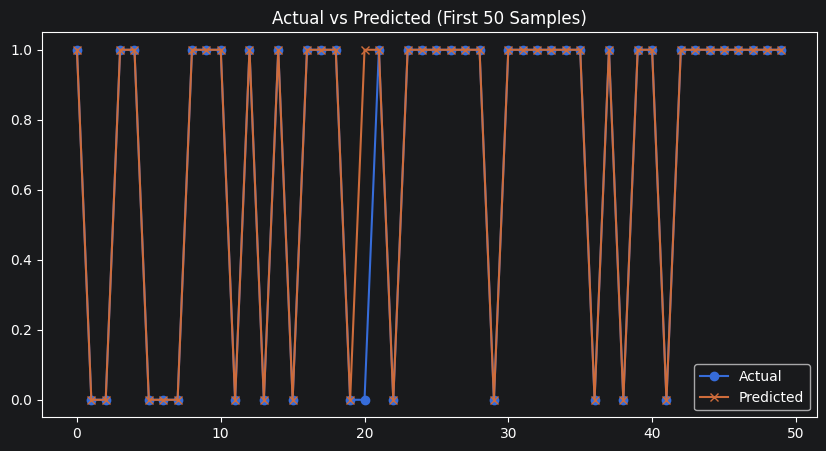

In [1]:
# ================================
# 1. 라이브러리 import
# ================================

# 데이터 처리용 라이브러리
import numpy as np
import pandas as pd

# 시각화 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns

# 머신러닝 관련 라이브러리
from sklearn.datasets import load_breast_cancer  # 예제 데이터
from sklearn.model_selection import train_test_split  # 데이터 분할
from sklearn.preprocessing import StandardScaler  # 정규화
from sklearn.linear_model import LogisticRegression  # 모델
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

# ================================
# 2. 데이터 로드
# ================================

# 유방암 데이터셋 로드 (이진 분류 문제)
data = load_breast_cancer()

# 입력 변수 (Feature)
X = data.data

# 정답 (Target)
y = data.target

# ================================
# 3. 데이터 분할 (Train/Test)
# ================================

# 데이터를 학습용 / 테스트용으로 분할
# test_size=0.2 → 20%를 테스트로 사용
# random_state → 결과 재현 가능
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ================================
# 4. 데이터 전처리 (정규화)
# ================================

# StandardScaler 생성 (평균=0, 표준편차=1)
scaler = StandardScaler()

# 학습 데이터로 scaler 학습 후 변환
X_train = scaler.fit_transform(X_train)

# 테스트 데이터는 transform만 수행 (fit 금지!)
X_test = scaler.transform(X_test)

# ================================
# 5. 모델 생성 및 학습
# ================================

# Logistic Regression 모델 생성
model = LogisticRegression()

# 모델 학습
model.fit(X_train, y_train)

# ================================
# 6. 예측 수행
# ================================

# 클래스 예측 (0 또는 1)
y_pred = model.predict(X_test)

# 확률 예측 (ROC 계산용)
y_prob = model.predict_proba(X_test)[:, 1]

# ================================
# 7. 성능 평가
# ================================

# Accuracy 계산
acc = accuracy_score(y_test, y_pred)

# Precision 계산
precision = precision_score(y_test, y_pred)

# Recall 계산
recall = recall_score(y_test, y_pred)

# F1 Score 계산
f1 = f1_score(y_test, y_pred)

# 결과 출력
print("=== 모델 성능 ===")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# ================================
# 8. Confusion Matrix 시각화
# ================================

# Confusion Matrix 계산
cm = confusion_matrix(y_test, y_pred)

# Heatmap으로 시각화
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# 제목 및 라벨
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# 출력
plt.show()

# ================================
# 9. ROC Curve 시각화
# ================================

# FPR, TPR 계산
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC 계산
roc_auc = auc(fpr, tpr)

# 그래프 그리기
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")

# 기준선 (random classifier)
plt.plot([0,1], [0,1], linestyle='--')

# 라벨 설정
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

# 범례
plt.legend()

# 출력
plt.show()

# ================================
# 10. 예측 결과 시각화
# ================================

# 실제값 vs 예측값 비교
plt.figure(figsize=(10,5))

# 실제값
plt.plot(y_test[:50], label="Actual", marker='o')

# 예측값
plt.plot(y_pred[:50], label="Predicted", marker='x')

# 제목 및 범례
plt.title("Actual vs Predicted (First 50 Samples)")
plt.legend()

# 출력
plt.show()